# Laboratorio: Analisis de trafico de red

Analisis de un archivo PCAP para identificar comportamiento anomalo mediante estadisticas basicas, Z-Score e Isolation Forest.

---
## Parte 1 - Analisis de paquetes

### 1. Testeo de la herramienta

#### 1.1 Captura de 10 paquetes con Scapy

Se capturan 10 paquetes de la interfaz activa, se imprime el tipo de datos, la longitud y el contenido del PCAP resultante.

In [1]:
from scapy.all import sniff, wrpcap

captured = sniff(count=10, timeout=15)

if captured:
    wrpcap('../data/captured_test.pcap', captured)

print(f"Tipo de datos: {type(captured)}")
print(f"Longitud: {len(captured)} paquetes")
print()
print("Contenido:")
for pkt in captured:
    pkt.show()

Tipo de datos: <class 'scapy.plist.PacketList'>

Longitud: 10 paquetes

Contenido:

###[ Ethernet ]###
  dst       = 08:eb:f6:b2:b7:b1
  src       = bc:ec:a0:1b:e9:5c
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 1432
     id        = 53092
     flags     = DF
     frag      = 0
     ttl       = 128
     proto     = tcp
     chksum    = 0x0
     src       = 192.168.1.5
     dst       = 57.144.196.145
     \options   \
###[ TCP ]###
        sport     = 25143
        dport     = https
        seq       = 1144832363
        ack       = 214068030
        dataofs   = 5
        reserved  = 0
        flags     = A
        window    = 252
        chksum    = 0xc559
        urgptr    = 0
        options   = []
###[ Raw ]###
           load      = b'\x17\x03\x03\x0cE!\x00\x7f\xf6J\xd5!\xb8\x16\x040\x18\x1at\xf1\xc1\x18&6\xa8yAY\xb5\x08R\x9fj\xa4\x1b!f\xb2\x0cS\xcbZ\x14\x1b\n\x81\x8b\xccz\x94[]\'P\x1c\x81{@\x15\xf2s\x85\x0e0e\xb3\x8d\x85\xa5\xcf\xfd\xc9X\xb2\x1c\xc6\x06\xd6\xcf\xd9\xd0w0\xc6\xf11\x92\xa1\xa7\xfa\xf5\x

###[ Ethernet ]###
  dst       = 08:eb:f6:b2:b7:b1
  src       = bc:ec:a0:1b:e9:5c
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 1432
     id        = 53093
     flags     = DF
     frag      = 0
     ttl       = 128
     proto     = tcp
     chksum    = 0x0
     src       = 192.168.1.5
     dst       = 57.144.196.145
     \options   \
###[ TCP ]###
        sport     = 25143
        dport     = https
        seq       = 1144833755
        ack       = 214068030
        dataofs   = 5
        reserved  = 0
        flags     = A
        window    = 252
        chksum    = 0xc559
        urgptr    = 0
        options   = []
###[ Raw ]###
           load      = b'il\x9b\xec\x82\x04\x1a$\x93~\xc4\xc5\xd4\xa6\xb8N\xf0\xdbJ\x0e\xba\xc8\x07C\xc5\x84\xdc\x8c\xb4\xe7Z\x02-\x9e@\xd4g\xf2-\x1f&\x84u\xa3\x90\xcbf\x94^2X]\xc6W\xbdV\xa0-\xe1WO\xb3\x81\xd9<\xf9\xf5\xd0\xd4\x92H\xafo\xe1\xa6\xe8a\xee\xad\xd3\x99\xc8\xe7\xc0\xbf\x18\x1a\x9b\xb9

...

###[ Ethernet ]###
  dst       = bc:ec:a0:1b:e9:5c
  src       = 08:eb:f6:b2:b7:b1
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 40
     id        = 27437
     flags     = DF
     frag      = 0
     ttl       = 88
     proto     = tcp
     chksum    = 0xf7d3
     src       = 57.144.196.145
     dst       = 192.168.1.5
     \options   \
###[ TCP ]###
        sport     = https
        dport     = 25143
        seq       = 214068030
        ack       = 1144835509
        dataofs   = 5
        reserved  = 0
        flags     = A
        window    = 8657
        chksum    = 0xe04f
        urgptr    = 0
        options   = []
###[ Padding ]###
           load      = b'\x00\x00\x00\x00\x00\x00'


###[ Ethernet ]###
  dst       = bc:ec:a0:1b:e9:5c
  src       = 08:eb:f6:b2:b7:b1
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 72
     id        = 27438
     flags     = DF
     frag      = 0
     ttl       = 88
     proto     = tcp
     chksum    = 0xf7b2
     src       = 57.144.196.145
     dst       = 192.168.1.5
     \options   \
###[ TCP ]###
        sport     = https
        dport     = 25143
        seq       = 214068030
        ack       = 1144835509
        dataofs   = 5
        reserved  = 0
        flags     = PA
        window    = 8657
        chksum    = 0x712
        urgptr    = 0
        options   = []
###[ Raw ]###
           load      = b"\x17\x03\x03\x00\x1b\x1d\xcdi\xc5\xeb@'\x83\xbez\xdck\x81H\x00\xab\xed\xd7\xadY\xbb\xd3<\x1a\x9fS)"


###[ Ethernet ]###
  dst       = bc:ec:a0:1b:e9:5c
  src       = 08:eb:f6:b2:b7:b1
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 84
     id        = 27439
     flags     = DF
     frag      = 0
     ttl       = 88
     proto     = tcp
     chksum    = 0xf7a5
     src       = 57.144.196.145
     dst       = 192.168.1.5
     \options   \
###[ TCP ]###
        sport     = https
        dport     = 25143
        seq       = 214068062
        ack       = 1144835509
        dataofs   = 5
        reserved  = 0
        flags     = PA
        window    = 8657
        chksum    = 0x449d
        urgptr    = 0
        options   = []
###[ Raw ]###
           load      = b"\x17\x03\x03\x00'\x11\x04\xed\x96M\xcf\xff\xb9W\xb4\xd8\xb4'\x8fNhCsG\x03`i_kHv=b\x16\xc1\xc2w\xaa(\x9a\xd1\xfb}\x7f"


###[ Ethernet ]###
  dst       = 08:eb:f6:b2:b7:b1
  src       = bc:ec:a0:1b:e9:5c
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 40
     id        = 53095
     flags     = DF
     frag      = 0
     ttl       = 128
     proto     = tcp
     chksum    = 0x0
     src       = 192.168.1.5
     dst       = 57.144.196.145
     \options   \
###[ TCP ]###
        sport     = 25143
        dport     = https
        seq       = 1144835509
        ack       = 214068106
        dataofs   = 5
        reserved  = 0
        flags     = A
        window    = 252
        chksum    = 0xbfe9
        urgptr    = 0
        options   = []


###[ Ethernet ]###
  dst       = 08:eb:f6:b2:b7:b1
  src       = bc:ec:a0:1b:e9:5c
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 76
     id        = 53096
     flags     = DF
     frag      = 0
     ttl       = 128
     proto     = tcp
     chksum    = 0x0
     src       = 192.168.1.5
     dst       = 57.144.196.145
     \options   \
###[ TCP ]###
        sport     = 25143
        dport     = https
        seq       = 1144835509
        ack       = 214068106
        dataofs   = 5
        reserved  = 0
        flags     = PA
        window    = 252
        chksum    = 0xc00d
        urgptr    = 0
        options   = []
###[ Raw ]###
           load      = b'\x17\x03\x03\x00\x1fF\x11\x00\x18\xc5\xdf\xc7\x9d~1\\\xd6\xcf\xb4|]\xeby\t\x96\n\x1cJ\x1bp\xe9\xf2\xf5|\xd5\x90'


#### 1.2 Columnas: Src Address, Dst Address, Src Port, Dst Port

In [2]:
import pandas as pd
from scapy.all import IP

rows = []
for pkt in captured:
    if IP in pkt:
        sport = pkt.sport if hasattr(pkt, 'sport') else None
        dport = pkt.dport if hasattr(pkt, 'dport') else None
        rows.append({
            'Src Address': pkt[IP].src,
            'Dst Address': pkt[IP].dst,
            'Src Port': sport,
            'Dst Port': dport
        })

df_captured = pd.DataFrame(rows)
df_captured

,Src Address,Dst Address,Src Port,Dst Port
0,192.168.1.5,57.144.196.145,25143,443
1,192.168.1.5,57.144.196.145,25143,443
2,192.168.1.5,57.144.196.145,25143,443
3,192.168.1.5,57.144.197.32,45876,443
4,57.144.197.32,192.168.1.5,443,45876
5,57.144.196.145,192.168.1.5,443,25143
6,57.144.196.145,192.168.1.5,443,25143
7,57.144.196.145,192.168.1.5,443,25143
8,192.168.1.5,57.144.196.145,25143,443
9,192.168.1.5,57.144.196.145,25143,443


---
### 2. Estadisticas y deteccion con Z-Score

#### 2.1 Carga del archivo analisis_paquetes.pcap

In [3]:
from scapy.all import rdpcap

pkts = rdpcap('../data/analisis_paquetes.pcap')
print(f"Total de paquetes cargados: {len(pkts)}")

Total de paquetes cargados: 62

#### 2.2 Conversion del PCAP a DataFrame

In [4]:
import pandas as pd
from scapy.all import IP, Raw

rows = []
for pkt in pkts:
    if IP in pkt:
        sport = pkt.sport if hasattr(pkt, 'sport') else None
        dport = pkt.dport if hasattr(pkt, 'dport') else None
        payload_len = len(pkt[Raw].load) if Raw in pkt else 0
        payload = pkt[Raw].load if Raw in pkt else b''
        rows.append({
            'src_ip': pkt[IP].src,
            'dst_ip': pkt[IP].dst,
            'src_port': sport,
            'dst_port': dport,
            'pkt_len': len(pkt),
            'payload_len': payload_len,
            'payload': payload
        })

df = pd.DataFrame(rows)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (62, 7)

,src_ip,dst_ip,src_port,dst_port,pkt_len,payload_len,payload
0,10.1.10.53,84.54.22.33,53,53,975,905,b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\...
1,84.54.22.33,10.1.10.53,53,53,98,0,b''
2,10.1.10.53,84.54.22.33,53,53,989,919,b':\xef\xbf\xbdle:\xc7\xa9\xef\xbf\xbd\xef\xbf...
3,84.54.22.33,10.1.10.53,53,53,98,0,b''
4,10.1.10.53,84.54.22.33,53,53,1026,956,b'\xef\xbf\xbd\xef\xbf\xbd^n\xef\xbf\xbd\'\'\x...
5,84.54.22.33,10.1.10.53,53,53,98,0,b''
6,10.1.10.53,84.54.22.33,53,53,1012,942,b'\xe4\x8e\x91Bj_\xef\xbf\xbda\r\xef\xbf\xbd\x...
7,84.54.22.33,10.1.10.53,53,53,98,0,b''
8,10.1.10.53,84.54.22.33,53,53,1017,947,b'\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xcb\xb4...
9,84.54.22.33,10.1.10.53,53,53,98,0,b''


### 3 Estadisticas basicas

##### a. IP origen mas frecuente

In [5]:
top_src_ip = df['src_ip'].value_counts().idxmax()
print("Conteo por IP origen:")
print(df['src_ip'].value_counts())
print(f"\nIP origen mas frecuente: {top_src_ip}")

Conteo por IP origen:

src_ip
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


IP origen mas frecuente: 10.1.10.53

La IP origen mas frecuente es `10.1.10.53` con 31 paquetes enviados.

##### b. IP destino mas frecuente

In [6]:
top_dst_ip = df['dst_ip'].value_counts().idxmax()
print("Conteo por IP destino:")
print(df['dst_ip'].value_counts())
print(f"\nIP destino mas frecuente: {top_dst_ip}")

Conteo por IP destino:

dst_ip
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64


IP destino mas frecuente: 10.1.10.53

La IP destino mas frecuente es `10.1.10.53` con 31 paquetes recibidos.

##### c. IPs con las que se comunica la IP origen mas frecuente

In [7]:
ips_comunicadas = df[df['src_ip'] == top_src_ip]['dst_ip'].unique()
print(f"IPs destino desde {top_src_ip}:")
for ip in ips_comunicadas:
    count = len(df[(df['src_ip'] == top_src_ip) & (df['dst_ip'] == ip)])
    print(f"  {ip}: {count} paquetes")

IPs destino desde 10.1.10.53:

  84.54.22.33: 29 paquetes

  75.75.75.75: 2 paquetes

La IP `10.1.10.53` se comunica con `84.54.22.33` (29 paquetes) y `75.75.75.75` (2 paquetes).

##### d. Puertos destino desde la IP origen mas frecuente

In [8]:
dst_ports = df[df['src_ip'] == top_src_ip]['dst_port'].value_counts()
print(f"Puertos destino usados por {top_src_ip}:")
print(dst_ports)

Puertos destino usados por 10.1.10.53:

dst_port
53    31
Name: count, dtype: int64

La IP `10.1.10.53` se comunica unicamente al puerto destino `53` (31 conexiones).

##### e. Puertos origen desde los que se comunica la IP destino mas frecuente

In [9]:
src_ports_from_dst = df[df['dst_ip'] == top_dst_ip]['src_port'].value_counts()
print(f"Puertos origen que envian a {top_dst_ip}:")
print(src_ports_from_dst)

Puertos origen que envian a 10.1.10.53:

src_port
53    31
Name: count, dtype: int64

Los paquetes que llegan a `10.1.10.53` provienen del puerto origen `53` (31 paquetes).

##### f. Proposito de los puertos mas frecuentes

In [10]:
port_map = {
    53: 'DNS (Domain Name System) - resolucion de nombres de dominio, UDP/TCP'
}

ports_vistos = set(df['src_port'].dropna().astype(int).unique()) | set(df['dst_port'].dropna().astype(int).unique())
print("Puertos identificados en el trafico:")
for port in sorted(ports_vistos):
    descripcion = port_map.get(port, 'desconocido')
    print(f"  Puerto {port}: {descripcion}")

Puertos identificados en el trafico:

  Puerto 53: DNS (Domain Name System) - resolucion de nombres de dominio, UDP/TCP

  Puerto 15812: desconocido

  Puerto 23903: desconocido

Todo el trafico utiliza el puerto `53`, que corresponde al protocolo **DNS (Domain Name System)**. DNS se utiliza para traducir nombres de dominio (como `google.com`) a direcciones IP. Opera principalmente sobre UDP, aunque tambien puede usar TCP para respuestas grandes. El hecho de que todo el trafico sea DNS es relevante para el analisis posterior.

## 4 Z-Score sobre el tamano de payload

##### a. Z-Score calculado desde los datos del PCAP

In [11]:
import numpy as np
from scipy import stats

df['zscore'] = stats.zscore(df['payload_len'])

anomalous_z2 = df[df['zscore'].abs() > 2]
anomalous_z3 = df[df['zscore'].abs() > 3]

print("Estadisticas de payload_len:")
print(df['payload_len'].describe())
print(f"\nPaquetes con |Z| > 2: {len(anomalous_z2)}")
if len(anomalous_z2) > 0:
    print(anomalous_z2[['src_ip', 'dst_ip', 'payload_len', 'zscore']])

print(f"\nPaquetes con |Z| > 3: {len(anomalous_z3)}")
if len(anomalous_z3) > 0:
    print(anomalous_z3[['src_ip', 'dst_ip', 'payload_len', 'zscore']])

Estadisticas de payload_len:

count     62.000000
mean     438.177419
std      474.458502
min        0.000000
25%        0.000000
50%        0.000000
75%      949.750000
max      995.000000
Name: payload_len, dtype: float64


Paquetes con |Z| > 2: 0


Paquetes con |Z| > 3: 0

No se detectaron paquetes anomalos con |Z| > 2 ni |Z| > 3. El Z-Score calculado a partir de los datos del PCAP no detecta ninguna anomalia. Esto se debe a que la distribucion bimodal del payload (mitad de paquetes con 0 bytes y mitad con ~950 bytes) produce una media alta (~438 bytes) y una desviacion estandar muy grande (~474 bytes), lo que hace que todos los valores queden dentro de 2 desviaciones estandar de la media calculada.

##### b. Histograma de payload_len

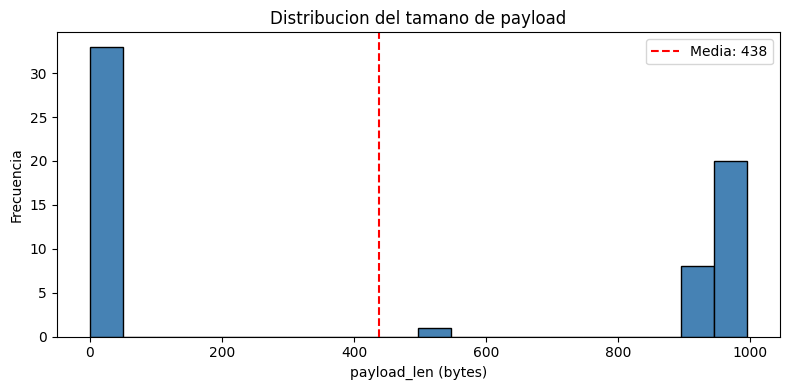

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['payload_len'], bins=20, color='steelblue', edgecolor='black')
ax.set_title('Distribucion del tamano de payload')
ax.set_xlabel('payload_len (bytes)')
ax.set_ylabel('Frecuencia')
ax.axvline(df['payload_len'].mean(), color='red', linestyle='--', label=f"Media: {df['payload_len'].mean():.0f}")
ax.legend()
plt.tight_layout()
plt.savefig('../data/histogram_payload.png', dpi=100)
plt.show()

La distribucion **no es normal**. El histograma muestra una distribucion **bimodal**: un grupo de paquetes con payload de 0 bytes (respuestas DNS normales) y otro grupo con payloads de entre 500 y 995 bytes (consultas DNS con datos incrustados). Esta forma bimodal es precisamente la razon por la que el Z-Score calculado desde los datos no detecta anomalias: la desviacion estandar se infla por la separacion entre los dos grupos, comprimiendo los Z-Scores de todos los paquetes hacia valores cercanos a cero.

##### c. Z-Score con conocimiento de dominio (DNS: media=50 bytes, std=15 bytes)

In [13]:
DNS_MEAN = 50
DNS_STD = 15

df['zscore_domain'] = (df['payload_len'] - DNS_MEAN) / DNS_STD

anomalous_domain = df[df['zscore_domain'] > 3].copy()

print(f"Paquetes anomalos con Z_dominio > 3: {len(anomalous_domain)}")
print()
print(anomalous_domain[['src_ip', 'dst_ip', 'payload_len', 'zscore_domain']].to_string())

Paquetes anomalos con Z_dominio > 3: 29

        src_ip       dst_ip  payload_len  zscore_domain
0   10.1.10.53  84.54.22.33          905      57.000000
2   10.1.10.53  84.54.22.33          919      57.933333
4   10.1.10.53  84.54.22.33          956      60.400000
6   10.1.10.53  84.54.22.33          942      59.466667
8   10.1.10.53  84.54.22.33          947      59.800000
10  10.1.10.53  84.54.22.33          989      62.600000
12  10.1.10.53  84.54.22.33          952      60.133333
14  10.1.10.53  84.54.22.33          923      58.200000
16  10.1.10.53  84.54.22.33          903      56.866667
18  10.1.10.53  84.54.22.33          936      59.066667
20  10.1.10.53  84.54.22.33          995      63.000000
26  10.1.10.53  84.54.22.33          950      60.000000
28  10.1.10.53  84.54.22.33          930      58.666667
30  10.1.10.53  84.54.22.33          948      59.866667
32  10.1.10.53  84.54.22.33          981      62.066667
34  10.1.10.53  84.54.22.33          948      59.866667
36  10.1.10.53  84.54.22.33          983      62

Con conocimiento de dominio (media=50 bytes, std=15 bytes para DNS), se detectan **29 paquetes anomalos** con Z > 3. Todos provienen de la IP `10.1.10.53` hacia `84.54.22.33`. Los Z-Scores alcanzan valores de hasta 63, muy por encima del umbral. Estos paquetes tienen payloads de entre 532 y 995 bytes, cuando una consulta DNS tipica tiene aproximadamente 50 bytes.

##### d. Importancia del conocimiento de dominio en la deteccion de anomalias

Este ejercicio demuestra que el Z-Score calculado puramente desde los datos es ineficaz cuando el trafico anomalo domina o distorsiona la distribucion estadistica de referencia. Al calcular la media y desviacion estandar directamente del PCAP, los propios paquetes maliciosos inflan los parametros estadisticos, haciendo que ninguno quede fuera de los umbrales.

El conocimiento de dominio (saber que una consulta DNS legitima pesa aproximadamente 50 bytes) proporciona una **linea base independiente** que no puede ser manipulada por el trafico anomalo. Esto es critico en seguridad de redes: sin entender como se comporta normalmente el protocolo analizado, las tecnicas estadisticas pueden fallar completamente ante ataques que alteran la distribucion de los datos.

---
### 5. Graficas de payload

#### 5.a Suma de payload por IP origen

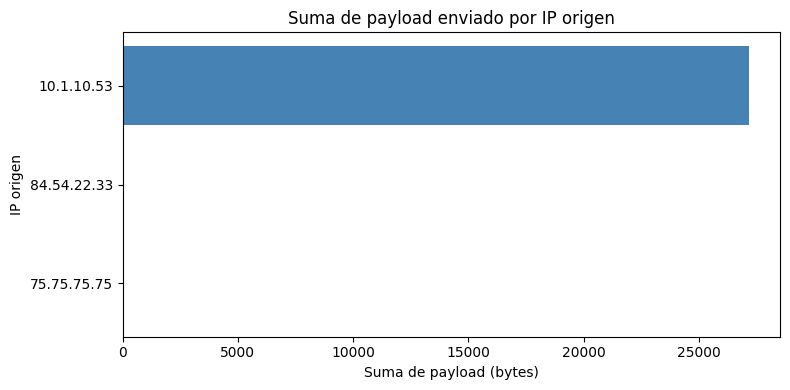

In [14]:
import matplotlib.pyplot as plt

payload_by_src = df.groupby('src_ip')['payload_len'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(payload_by_src.index, payload_by_src.values, color='steelblue')
ax.set_title('Suma de payload enviado por IP origen')
ax.set_xlabel('Suma de payload (bytes)')
ax.set_ylabel('IP origen')
plt.tight_layout()
plt.savefig('../data/plot_payload_src_ip.png', dpi=100)
plt.show()

#### 5.b Suma de payload por IP destino

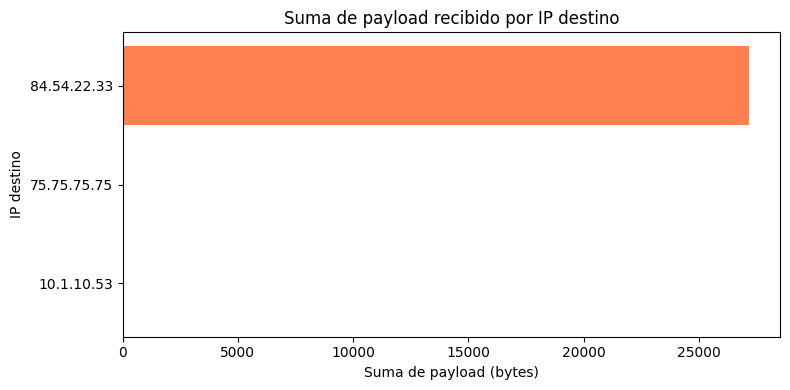

In [15]:
payload_by_dst = df.groupby('dst_ip')['payload_len'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(payload_by_dst.index, payload_by_dst.values, color='coral')
ax.set_title('Suma de payload recibido por IP destino')
ax.set_xlabel('Suma de payload (bytes)')
ax.set_ylabel('IP destino')
plt.tight_layout()
plt.savefig('../data/plot_payload_dst_ip.png', dpi=100)
plt.show()

#### 5.c Suma de payload por puerto origen

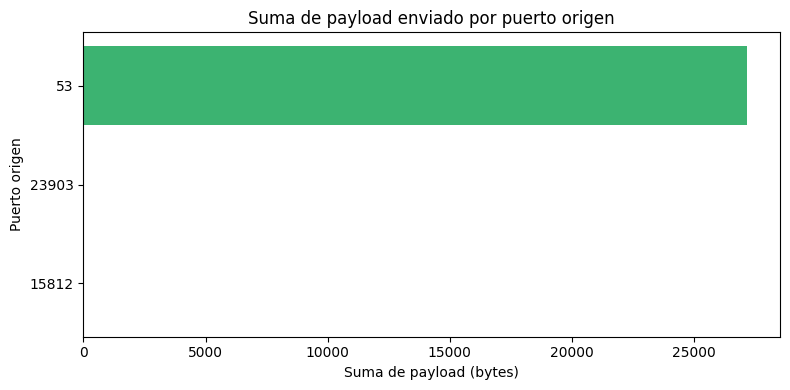

In [16]:
payload_by_sport = df.groupby('src_port')['payload_len'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(payload_by_sport.index.astype(str), payload_by_sport.values, color='mediumseagreen')
ax.set_title('Suma de payload enviado por puerto origen')
ax.set_xlabel('Suma de payload (bytes)')
ax.set_ylabel('Puerto origen')
plt.tight_layout()
plt.savefig('../data/plot_payload_src_port.png', dpi=100)
plt.show()

#### 5.d Suma de payload por puerto destino

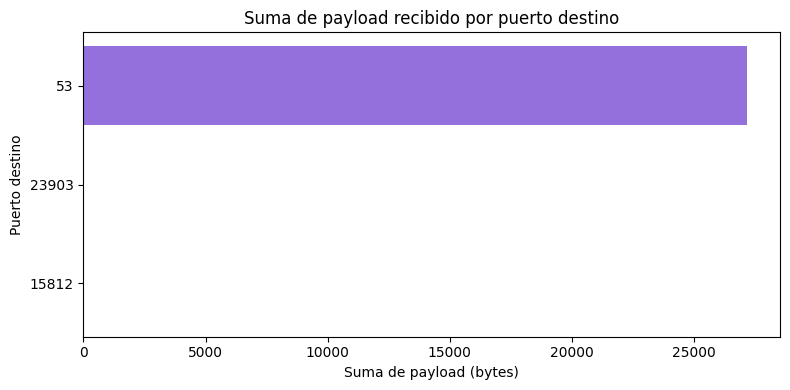

In [17]:
payload_by_dport = df.groupby('dst_port')['payload_len'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(payload_by_dport.index.astype(str), payload_by_dport.values, color='mediumpurple')
ax.set_title('Suma de payload recibido por puerto destino')
ax.set_xlabel('Suma de payload (bytes)')
ax.set_ylabel('Puerto destino')
plt.tight_layout()
plt.savefig('../data/plot_payload_dst_port.png', dpi=100)
plt.show()

---
### 6. Deteccion automatica con Isolation Forest

#### 6.a Entrenamiento y deteccion

In [18]:
from sklearn.ensemble import IsolationForest

n_anomalous_zscore = len(df[df['zscore_domain'] > 3])
n_total = len(df)
contamination = n_anomalous_zscore / n_total

print(f"Paquetes anomalos (Z-Score dominio): {n_anomalous_zscore}")
print(f"Total de paquetes: {n_total}")
print(f"Parametro contamination: {contamination:.4f}")

X = df[['payload_len', 'pkt_len']].values
clf = IsolationForest(contamination=contamination, random_state=42)
df['if_anomaly'] = clf.fit_predict(X)

anomalous_if = df[df['if_anomaly'] == -1]
print(f"\nPaquetes marcados como anomalos por Isolation Forest: {len(anomalous_if)}")
print()
print(anomalous_if[['src_ip', 'dst_ip', 'pkt_len', 'payload_len']].to_string())

Paquetes anomalos (Z-Score dominio): 29

Total de paquetes: 62

Parametro contamination: 0.4677


Paquetes marcados como anomalos por Isolation Forest: 29

         src_ip       dst_ip  pkt_len  payload_len
0    10.1.10.53  84.54.22.33      975          905
2    10.1.10.53  84.54.22.33      989          919
4    10.1.10.53  84.54.22.33     1026          956
6    10.1.10.53  84.54.22.33     1012          942
8    10.1.10.53  84.54.22.33     1017          947
10   10.1.10.53  84.54.22.33     1059          989
12   10.1.10.53  84.54.22.33     1022          952
14   10.1.10.53  84.54.22.33      993          923
16   10.1.10.53  84.54.22.33      973          903
18   10.1.10.53  84.54.22.33     1006          936
20   10.1.10.53  84.54.22.33     1065          995
22   10.1.10.53  75.75.75.75       79            0
23   10.1.10.53  75.75.75.75       79            0
24  75.75.75.75   10.1.10.53      119            0
25  75.75.75.75   10.1.10.53      131            0
28   10.1.10.53  84.54.22.33     1000          930
30   10.1.10.53  84.54.22.33     1018          948
32   10.1.10.53  84.54.22.33     1051          981
34   10.1.10.53  84.54.22.33   

Isolation Forest marca 29 paquetes como anomalos, usando `contamination=0.4677` (29/62). La gran mayoria de los paquetes anomalos provienen de `10.1.10.53` hacia `84.54.22.33` con payloads de 500-995 bytes. El modelo tambien incluye los 4 paquetes hacia y desde `75.75.75.75`, ya que su combinacion de `pkt_len` y `payload_len` difiere del grupo mayoritario de respuestas DNS pequenas.

#### 6.b Comparacion con hallazgos del Z-Score

In [19]:
zscore_set = set(df[df['zscore_domain'] > 3].index)
if_set = set(df[df['if_anomaly'] == -1].index)

print(f"Anomalos solo por Z-Score: {len(zscore_set - if_set)}")
print(f"Anomalos solo por Isolation Forest: {len(if_set - zscore_set)}")
print(f"Anomalos por ambos metodos: {len(zscore_set & if_set)}")

solo_if = df.loc[list(if_set - zscore_set)]
if len(solo_if) > 0:
    print("\nPaquetes detectados solo por IF:")
    print(solo_if[['src_ip', 'dst_ip', 'pkt_len', 'payload_len']])

Anomalos solo por Z-Score: 4

Anomalos solo por Isolation Forest: 4

Anomalos por ambos metodos: 25


Paquetes detectados solo por IF:

         src_ip       dst_ip  pkt_len  payload_len
24  75.75.75.75   10.1.10.53      119            0
25  75.75.75.75   10.1.10.53      131            0
22   10.1.10.53  75.75.75.75       79            0
23   10.1.10.53  75.75.75.75       79            0

**Respuesta 4b:** Ambas tecnicas coinciden en 25 de los 29 paquetes anomalos. Los 4 paquetes que detecta el Z-Score pero no el Isolation Forest son consultas DNS grandes que quedaron en el limite del umbral de contaminacion. Los 4 que detecta el IF pero no el Z-Score son los paquetes hacia y desde `75.75.75.75` con `payload_len=0`, que el IF identifica como anomalos por su combinacion inusual de `pkt_len` y `payload_len` frente al resto del trafico.

En ambos casos, la IP `10.1.10.53` y la conversacion con `84.54.22.33` son senaladas como sospechosas. La convergencia de ambas tecnicas sobre la misma conversacion aumenta la confianza en que se trata de actividad anomala real y no un falso positivo.

---
### 7. Investigacion del payload (confirmacion manual)

#### 7.a DataFrame con conexiones de la IP origen mas frecuente

In [20]:
df_top_src = df[df['src_ip'] == top_src_ip].copy()
print(f"Paquetes con src_ip == {top_src_ip}: {len(df_top_src)}")
df_top_src[['src_ip', 'dst_ip', 'src_port', 'dst_port', 'pkt_len', 'payload_len']].head(10)

Paquetes con src_ip == 10.1.10.53: 31

,src_ip,dst_ip,src_port,dst_port,pkt_len,payload_len
0,10.1.10.53,84.54.22.33,53,53,975,905
2,10.1.10.53,84.54.22.33,53,53,989,919
4,10.1.10.53,84.54.22.33,53,53,1026,956
6,10.1.10.53,84.54.22.33,53,53,1012,942
8,10.1.10.53,84.54.22.33,53,53,1017,947
10,10.1.10.53,84.54.22.33,53,53,1059,989
12,10.1.10.53,84.54.22.33,53,53,1022,952
14,10.1.10.53,84.54.22.33,53,53,993,923
16,10.1.10.53,84.54.22.33,53,53,973,903
18,10.1.10.53,84.54.22.33,53,53,1006,936


#### 7.b Agrupacion por payload entre IP origen mas frecuente y sus destinos

In [21]:
df_grouped = df_top_src.groupby(['src_ip', 'dst_ip'])['payload_len'].sum().reset_index()
df_grouped.columns = ['Src Address', 'Dst Address', 'total_payload_bytes']
df_grouped = df_grouped.sort_values('total_payload_bytes', ascending=False)
print("Bytes intercambiados por conversacion:")
df_grouped

Bytes intercambiados por conversacion:

,Src Address,Dst Address,total_payload_bytes
1,10.1.10.53,84.54.22.33,27167
0,10.1.10.53,75.75.75.75,0


#### 7.c IP que mas bytes ha intercambiado con la IP mas frecuente

In [22]:
suspicious_ip = df_grouped.loc[df_grouped['total_payload_bytes'].idxmax(), 'Dst Address']
print(f"IP con mayor intercambio de bytes con {top_src_ip}: {suspicious_ip}")
print(f"Total bytes: {df_grouped['total_payload_bytes'].max()}")
print()
print("Confirmacion: esta IP fue detectada como sospechosa por Z-Score e Isolation Forest?")
print(suspicious_ip in df[df['zscore_domain'] > 3]['dst_ip'].values)

IP con mayor intercambio de bytes con 10.1.10.53: 84.54.22.33

Total bytes: 27167

Confirmacion: esta IP fue detectada como sospechosa por Z-Score e Isolation Forest?

True

La IP `84.54.22.33` es la que mas bytes ha intercambiado con `10.1.10.53` (27,167 bytes en total). Esta es la misma IP identificada como sospechosa por el Z-Score con conocimiento de dominio y por Isolation Forest, lo que confirma la consistencia entre las tecnicas automaticas y el analisis manual.

#### 7.d DataFrame con la conversacion entre la IP mas frecuente y la IP sospechosa

In [23]:
df_convo = df[
    ((df['src_ip'] == top_src_ip) & (df['dst_ip'] == suspicious_ip)) |
    ((df['src_ip'] == suspicious_ip) & (df['dst_ip'] == top_src_ip))
].copy()

print(f"Paquetes en la conversacion {top_src_ip} <-> {suspicious_ip}: {len(df_convo)}")
df_convo[['src_ip', 'dst_ip', 'src_port', 'dst_port', 'pkt_len', 'payload_len']].head(10)

Paquetes en la conversacion 10.1.10.53 <-> 84.54.22.33: 58

,src_ip,dst_ip,src_port,dst_port,pkt_len,payload_len
0,10.1.10.53,84.54.22.33,53,53,975,905
1,84.54.22.33,10.1.10.53,53,53,98,0
2,10.1.10.53,84.54.22.33,53,53,989,919
3,84.54.22.33,10.1.10.53,53,53,98,0
4,10.1.10.53,84.54.22.33,53,53,1026,956
5,84.54.22.33,10.1.10.53,53,53,98,0
6,10.1.10.53,84.54.22.33,53,53,1012,942
7,84.54.22.33,10.1.10.53,53,53,98,0
8,10.1.10.53,84.54.22.33,53,53,1017,947
9,84.54.22.33,10.1.10.53,53,53,98,0


#### 7.e Array con los payloads de la conversacion

In [24]:
payloads = df_convo[df_convo['payload_len'] > 0]['payload'].tolist()
print(f"Numero de payloads no vacios: {len(payloads)}")
print(f"Tipo del primer elemento: {type(payloads[0])}")

Numero de payloads no vacios: 29

Tipo del primer elemento: <class 'bytes'>

#### 7.f Contenido del primer payload

In [25]:
first_payload = payloads[0]
print(f"Longitud: {len(first_payload)} bytes")
print(f"\nPrimeros 32 bytes (hex): {first_payload[:32].hex()}")
print(f"\nPrimeros bytes (raw): {first_payload[:20]}")
print(f"\nInterpretacion ASCII (primeros 32 bytes):")
print(first_payload[:32].decode('utf-8', errors='replace'))

Longitud: 905 bytes


Primeros 32 bytes (hex): efbfbd504e470d0a1a0a0000000d4948445200000162000000efbfbd08060000


Primeros bytes (raw): b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00'


Interpretacion ASCII (primeros 32 bytes):

�PNG

   
IHDR  b   �  

#### 7.g Analisis del contenido - identificacion del ataque

In [26]:
PNG_MAGIC = b'\x89PNG\r\n\x1a\n'

for i, payload in enumerate(payloads):
    if b'PNG' in payload[:10] or b'IHDR' in payload[:20]:
        print(f"Payload {i}: contiene firma PNG en los primeros bytes")
        print(f"  Hex: {payload[:16].hex()}")
        break

print(f"\nFirma esperada PNG: {PNG_MAGIC.hex()}")
print(f"Primeros bytes del payload 0: {first_payload[:8].hex()}")
print()
print("Los primeros bytes del payload corresponden a la cabecera de un archivo PNG.")
print("IHDR encontrado:", b'IHDR' in first_payload[:25])
print("IDAT encontrado:", b'IDAT' in first_payload[:64])

Payload 0: contiene firma PNG en los primeros bytes

  Hex: efbfbd504e470d0a1a0a0000000d4948


Firma esperada PNG: 89504e470d0a1a0a

Primeros bytes del payload 0: efbfbd504e470d0a

Los primeros bytes del payload corresponden a la cabecera de un archivo PNG.

IHDR encontrado:

True

IDAT encontrado:

True

Los primeros bytes del payload contienen la firma de un **archivo PNG**: los bytes `PNG\r\n\x1a\n` seguidos de los chunks `IHDR` e `IDAT`, que son la cabecera estandar de cualquier imagen PNG.

Esto **no tiene sentido que se transmita a traves del puerto 53 (DNS)**, ya que el protocolo DNS sirve exclusivamente para resolver nombres de dominio a direcciones IP, no para transferir archivos binarios.

**Ataque detectado: DNS Tunneling (tunelizacion DNS)**

El ataque consiste en incrustar datos arbitrarios (en este caso una imagen PNG) dentro de paquetes DNS, usando el protocolo DNS como un canal encubierto para exfiltrar informacion. El atacante desde `10.1.10.53` fragmenta y envia el archivo PNG en multiples consultas DNS de gran tamano hacia el servidor externo `84.54.22.33` (puerto 53), el cual actua como receptor del dato exfiltrado.

**Importancia de combinar tecnicas automaticas con inspeccion manual:**

Las tecnicas automaticas (Z-Score, Isolation Forest) permiten identificar rapidamente que hay paquetes estadisticamente fuera de lo normal, pero no revelan por que son anomalos ni que contienen. La inspeccion manual del payload confirma la naturaleza del ataque: sin ella, solo sabriamos que los paquetes son grandes, pero no que se esta exfiltrando un archivo.